# APR + Phasor Workflow

Runs the full phasor calibration and lifetime analysis pipeline on raw BrightEyes MCS `.h5` data.
An optional **Adaptive Pixel Reassignment (APR)** step can be enabled via the `DO_APR` flag
in the parameters cell: the reassigned data overwrites `data_input` in memory before phasor
computation, so no intermediate file is written to disk.

### Workflow overview

1. **Calibration** — Correct per-channel timing offsets (channel skew) and instrument response
   using a reference dye of known lifetime.
2. **Load calibrated data** — Read the photon-count array and auxiliary traces (IRF, reference)
   from the HDF5 file.
3. **Photon flux check** *(optional)* — Verify the per-channel count rates.
4. **APR** *(optional)* — Apply Adaptive Pixel Reassignment to co-register all SPAD channels
   before analysis.
5. **Phasor computation** — Compute per-pixel phasors from the shift-corrected, channel-summed
   decay traces.
6. **Phasor correction** — Remove the instrument response (IRF or reference-dye calibration)
   from the phasors.
7. **Lifetime maps** — Derive τ_m and τ_φ maps and produce summary figures.


## Imports

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

MCS_FILE_SRC = ROOT.parent / "BrightEyes-MCS-File" / "src"
if MCS_FILE_SRC.exists() and str(MCS_FILE_SRC) not in sys.path:
    sys.path.insert(0, str(MCS_FILE_SRC))

import h5py
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

# APR
import brighteyes_ism.analysis.APR_lib as apr
import brighteyes_ism.analysis.Graph_lib as gr

# Phasor Workflow
import brighteyes_flim.tools_phasor as flim
import brighteyes_flim.graph_tools as graph
from brighteyes_mcs_file import Alignment, calibrate_h5_file, show_h5_structure_html, sum_channel_applying_shifts



/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Parameters

Edit only this cell before running the notebook.

| Parameter | Description |
|---|---|
| `FILE_REFERENCE` | Path to the reference dye `.h5` file (known lifetime `TAU_REF`) |
| `FILE_DATA` | Path to the raw acquisition `.h5` file |
| `DATA_KEY` | Which detector array to process: `'data'` (SPAD 5×5) or `'data_channels_extra'` (aux) |
| `TAU_REF` | Known fluorescence lifetime of the reference dye [ns] |
| `REFERENCE_TYPE` | `'ref'` for a lifetime reference dye, `'irf'` for a scattered-light IRF |
| `LASER_FREQ_MHZ` / `LASER_PERIOD_NS` | Laser timing — set to `None` to read from metadata |
| `OVERWRITE` | If `True`, recompute calibration even if a calibrated file already exists |
| `DO_APR` | Enable (`True`) or disable (`False`) Adaptive Pixel Reassignment |
| `ROI` | Pixel crop `(row_start, row_end, col_start, col_end)`; `None` = full field of view |
| `REF_CHANNEL` | Central SPAD channel used as reassignment reference (typically `12`) |
| `USF` | Sub-pixel up-sampling factor for shift estimation (higher = more precise, slower) |
| `REASSIGN_MODE` | `'interp'` (bilinear, recommended) or `'fft'` (Fourier-shift) |


In [2]:
# ── File paths ────────────────────────────────────────────────────────────

FILE_REFERENCE = r'/home/morlando1-iit.local/manuel/18052026_flim/FLIMLabs.h5'
FILE_DATA      = r'/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0.h5'

DATA_KEY = "data" # usual input key: ('data', 'data_channels_extra')
CALIBRATION_PRODUCT = {"data": "spad", "data_channels_extra": "aux"}[DATA_KEY]
INSPECT_DATA_KEY = DATA_KEY

# ── Calibration parameters ─────────────────────────────────────────────────

TAU_REF              = 2.5
REFERENCE_TYPE       = "ref"
FIT_MODE             = "model_shift"
FIT_TYPE             = "likelihood"
LASER_FREQ_MHZ       = None
LASER_PERIOD_NS      = None
CHANNEL_SKEW_SOURCE  = "ref"
OVERWRITE            = True

# ── APR parameters ─────────────────────────────────────────────────────────

# Set to True to apply pixel reassignment before phasor computation
DO_APR = True

# Spatial crop applied to image[0, 0, ...] as (row_start, row_end, col_start, col_end)
# Set to None to keep the full field of view
ROI = None #(1000, 1750, 1200, 1950)

# Index of the central detector element used as the reassignment reference
REF_CHANNEL = 12

# Sub-pixel up-sampling factor for shift-vector (higher = more accurate but slower)
USF = 100

# Pixel-reassignment interpolation mode: 'interp' (bilinear) or 'fft'
REASSIGN_MODE = "interp"




## Calibration

`calibrate_h5_file` processes the raw HDF5 data file and writes a calibrated copy containing
the aligned per-channel IRF and reference traces, the per-channel timing offsets (channel skew),
and the laser timing parameters.
If `OVERWRITE = True` the calibration is recomputed even if a calibrated file already exists.

> **Note:** `channel_skew_fit_reference_channel=12` uses the central SPAD pixel as the timing
> reference. `channel_skew_fit_upsampling=10` enables sub-bin precision in the cross-correlation.


In [3]:
FILE_WITH_CALIBRATION = calibrate_h5_file(
    FILE_DATA,
    FILE_REFERENCE,
    data_key=DATA_KEY,
    reference_type=REFERENCE_TYPE,
    tau_ref=TAU_REF,
    fit_mode=FIT_MODE,
    fit_type=FIT_TYPE,
    channel_skew_type="phase_cross_correlation",
    channel_skew_source=CHANNEL_SKEW_SOURCE,
    channel_skew_fit_reference_channel=12,
    channel_skew_fit_upsampling=10,
    channel_skew_fit_apodize=False,
    period_ns=LASER_PERIOD_NS,
    overwrite=OVERWRITE,
)
print(FILE_WITH_CALIBRATION)



/home/morlando1-iit.local/manuel/25052026_mito_tub_flim/25052026_tomm20_pxs100_0_calib.h5


## Load Calibrated Data

All arrays and metadata are read from the calibrated HDF5 file.

| Variable | Shape | Description |
|---|---|---|
| `data_input` | `(rep, z, y, x, t_bins, channels)` | Raw photon counts |
| `channel_skew` | `(channels,)` | Per-channel timing offset [bins] |
| `irf_common_delay_realigned` | `(t_bins, channels)` | Aligned IRF traces |
| `ref_common_delay_realigned` | `(t_bins, channels)` | Aligned reference-dye traces |
| `laser_freq_mhz` | scalar | Laser repetition frequency [MHz] |
| `laser_period_ns` | scalar | Laser period [ns] |
| `nbin` | scalar | Number of TCSPC time bins per period |
| `pixel_size_x_um` | scalar | Lateral pixel size [µm] |
| `pxdwelltime` | scalar | Pixel dwell time [µs] |


In [4]:
with h5py.File(FILE_WITH_CALIBRATION, "r") as hf:
    calibration = hf[f"calibration/results/{CALIBRATION_PRODUCT}"]
    metadata = hf["raw/metadata"]

    laser_freq_mhz  = float(calibration.attrs["laser_frequency_mhz"])
    laser_period_ns = float(calibration.attrs["laser_period_ns"])
    nbin            = int(metadata.attrs["time_bins"])
    pixel_size_x_um = float(metadata.attrs["pixel_size_x_um"])
    pxdwelltime     = float(metadata.attrs["pixel_dwell_time_us"])

    # data_input shape: (rep, z, y, x, t_bins, channels)
    data_input                  = hf[f"raw/{CALIBRATION_PRODUCT}"][:]
    channel_skew                = calibration["timing/channel_skew_bins"][:]
    irf_common_delay_realigned  = calibration["aligned/irf_trace"][:]
    ref_common_delay_realigned  = calibration["aligned/reference_trace"][:]

print(f"Using calibrated laser timing: {laser_freq_mhz:.4f} MHz ({laser_period_ns:.4f} ns)")
print(f"data_input shape: {data_input.shape}  (rep, z, y, x, t_bins, channels)")




Using calibrated laser timing: 40.0000 MHz (25.0000 ns)
data_input shape: (1, 1, 512, 512, 91, 25)  (rep, z, y, x, t_bins, channels)


## Photon Flux Per SPAD Channel

Compute the total photon count and the average count rate (flux) for each SPAD channel.

In [5]:
# Total photon counts per SPAD channel, summed over rep, z, x, y, and time bins
n_foton_per_channel = np.sum(data_input, axis=(0, 1, 2, 3, 4))
n_rep, n_frame, nx, ny = data_input.shape[0], data_input.shape[1], data_input.shape[2], data_input.shape[3]
n_px_total = n_rep * n_frame * nx * ny

# Count rate [Hz] = total photons per channel / total acquisition time
total_time_s = n_px_total * pxdwelltime * 1e-6
flux_per_channel = n_foton_per_channel / total_time_s  # shape: (25,)

# Mean flux across all channels (in kHz)
flux_total = flux_per_channel.sum()

print(f"Pixel dwell time:     {pxdwelltime:.3f} µs")
print(f"Total time of acquisition:  {total_time_s:.4f} s")
print(f"Mean flux total:  {flux_total * 1e-3:.2f} kHz")
print(f"Mean flux per channel (kHz):")
for i, val in enumerate(flux_per_channel, 1):
    print(f"{val *1e-3:<8.2f}", end="" if i % 5 != 0 else "\n")



Pixel dwell time:     182.000 µs
Total time of acquisition:  47.7102 s
Mean flux total:  1714.43 kHz
Mean flux per channel (kHz):
39.24   52.23   60.24   51.09   35.88   
52.01   86.45   115.45  93.62   51.64   
81.95   104.85  147.30  115.86  61.51   
47.31   79.00   99.60   81.96   49.83   
33.80   45.38   51.08   44.39   32.76   


## APR — Pixel Reassignment *(optional)*

Controlled by `DO_APR` in the parameters cell.
When enabled, the shift vectors are estimated from the intensity image (sum over time bins)
and the reassignment is then applied **independently to each time bin**, fully preserving the
TCSPC decay information required for phasor analysis.

`data_input` is overwritten in memory with the spatially-reassigned array;
all downstream cells are unaffected.

Shift vectors are printed in **nanometres** for physical interpretability
(pixel size is read from the metadata).


Shift vectors (dy, dx) per channel:
[[-170.25440313 -171.23287671]
 [-143.83561644  -67.5146771 ]
 [-130.1369863     6.84931507]
 [-127.20156556   64.57925636]
 [-125.2446184   126.22309198]
 [ -70.45009785 -145.7925636 ]
 [ -61.64383562  -60.66536204]
 [ -65.55772994    3.91389432]
 [ -69.47162427   63.60078278]
 [ -75.34246575  124.26614481]
 [   7.82778865 -130.1369863 ]
 [   6.84931507  -62.6223092 ]
 [   0.            0.        ]
 [  -4.89236791   61.64383562]
 [ -12.72015656  122.30919765]
 [  75.34246575 -128.18003914]
 [  68.49315068  -65.55772994]
 [  64.57925636   -4.89236791]
 [  54.79452055   58.70841487]
 [  38.16046967  107.63209393]
 [ 183.95303327 -147.74951076]
 [ 145.7925636   -69.47162427]
 [ 130.1369863    -7.82778865]
 [ 110.56751468   46.9667319 ]
 [  65.55772994   73.38551859]]


/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:550: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(shift[:, 0], shift[:, 1], s=80, c=color, edgecolors='black', cmap=cmap)


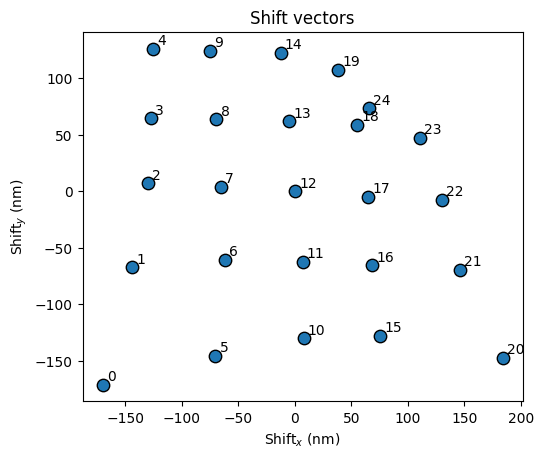

Reassigning time bins: 100%|██████████| 91/91 [01:04<00:00,  1.41it/s]

APR complete — data_input shape: (1, 1, 512, 512, 91, 25)


In [6]:
if DO_APR:

    # Select the first rep and z-plane -> (y, x, t_bins, channels)
    image_4D = data_input[0, 0, ...]

    # Apply the spatial crop if requested
    if ROI is not None:
        r0, r1, c0, c1 = ROI
        image_4D = image_4D[r0:r1, c0:c1, ...]
        print(f"ROI applied — cropped shape: {image_4D.shape}")

    # Collapse time bins to get the intensity image (y, x, channels),
    # used only for shift-vector estimation (time-independent operation)
    image_intensity = np.sum(image_4D, axis=-2)

    # Estimate sub-pixel shift vectors between each channel and the reference detector 
    # Returns: shift_vectors (n_channels, 2) — one (dy, dx) pair per channel [pixels]
    shift_vectors, estimation_error = apr.ShiftVectors(
        image_intensity, usf=USF, ref=REF_CHANNEL
    )

    # Convert shift vectors to nanometres for display
    pixel_size_nm = pixel_size_x_um * 1000
    shift_vectors_nm = shift_vectors * pixel_size_nm

    print("Shift vectors (dy, dx) per channel:")
    print(shift_vectors_nm)
    
    # Visualise the shift vectors on a grid matching the SPAD array geometry
    gr.PlotShiftVectors(shift_vectors_nm)
    plt.show()

    # Apply reassignment independently for each time bin and overwrite data_input
    n_x, n_y, n_bins, n_ch = image_4D.shape
    reassigned = np.empty_like(image_4D, dtype=np.float32)

    for b in tqdm(range(n_bins), desc="Reassigning time bins"):
        reassigned[:, :, b, :] = apr.Reassignment(
            shift_vectors,
            image_4D[:, :, b, :],
            mode=REASSIGN_MODE,
        )

    # Wrap back to (1, 1, x, y, t_bins, channels) to match the original shape
    data_input = reassigned[np.newaxis, np.newaxis, ...]   # overwrite in memory
    print(f"APR complete — data_input shape: {data_input.shape}")

else:
    print("APR skipped (DO_APR = False)")





## APR — Before / After Intensity Comparison

Sum over time bins and channels to produce a 2-D intensity image and compare
raw vs. reassigned side by side.
Both images are displayed with a physical scale bar and a calibrated colour scale
(counts per pixel dwell time).

**What to expect:**
- The APR image should appear sharper than the raw (finer features better resolved).
- The total intensity should be conserved; a small loss at the borders is normal
  (photons shifted outside the field of view are discarded by the interpolation).


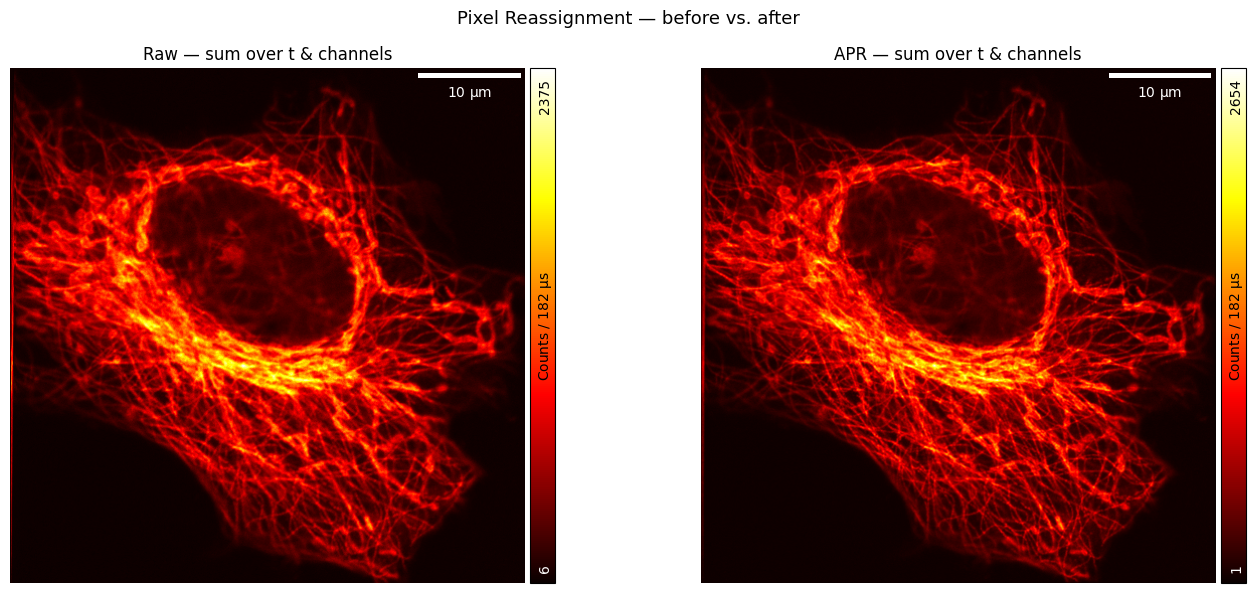

Raw image — min: 6  max: 2375
APR image — min: 1.0  max: 2654.0
Total counts — Raw: 81795747  APR: 83414760
Intensity conservation: 101.98% of raw counts retained


In [7]:
if DO_APR:
    # Sum over t_bins (axis -2) and channels (axis -1) → 2-D intensity map (y, x)
    intensity_raw = np.sum(image_4D,   axis=(-2, -1))
    intensity_apr = np.sum(reassigned, axis=(-2, -1))

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Use ShowImg to display images with a physical scale bar and calibrated colour scale,
    # matching the format used throughout the rest of the pipeline.
    gr.ShowImg(intensity_raw, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[0])
    axes[0].set_title("Raw — sum over t & channels")

    gr.ShowImg(intensity_apr, pixel_size_x_um, pxdwelltime, fig=fig, ax=axes[1])
    axes[1].set_title("APR — sum over t & channels")

    fig.suptitle("Pixel Reassignment — before vs. after", fontsize=13)
    fig.tight_layout()
    plt.show()

    print(f"Raw image — min: {intensity_raw.min():.0f}  max: {intensity_raw.max():.0f}")
    print(f"APR image — min: {intensity_apr.min():.1f}  max: {intensity_apr.max():.1f}")
    print(f"Total counts — Raw: {intensity_raw.sum():.0f}  APR: {intensity_apr.sum():.0f}")
    print(f"Intensity conservation: {100 * intensity_apr.sum() / intensity_raw.sum():.2f}% of raw counts retained")

else:
    print("DO_APR = False — skipping before/after comparison.")

## Compute Phasors

Before computing phasors, the per-channel TCSPC traces are summed across all 25 SPAD channels
with the timing-skew correction applied along the time axis (`sum_channel_applying_shifts`).
This yields a single spatially-resolved decay trace per pixel.

Three variants are computed for diagnostic purposes:
- **no alignment** — raw sum with no skew correction (reference only).
- **aligned** (default) — shift-corrected sum; used for all downstream analysis.
- **reversed** — sum with shifts applied in the opposite direction; used by
  `plot_channel_skew_correction` to verify that the calibration direction is correct.

> **Optional IRF cleaning** (`if False` block): `Alignment.clean_irf_stack` can suppress
> noisy tails in the IRF by zeroing bins outside a window around the peak. Enable it by
> changing `if False` to `if True` if your IRF shows significant baseline noise or ringing.
> Use this only when `REFERENCE_TYPE = 'ref'`; with `REFERENCE_TYPE = 'irf'` the IRF
> cleaning should be omitted or applied with care.


In [ ]:
# Optional: suppress baseline noise / ringing in the IRF traces.
# Enable by changing `if False` to `if True`.
# Recommended only when REFERENCE_TYPE = 'ref'.
if False:
    irf_common_delay_realigned = Alignment.clean_irf_stack(
        irf_common_delay_realigned,
        threshold=0.3,
        window=2 / (laser_period_ns / nbin),
        time_axis=0,
        normalize=True,
    )

data_summed_no_alignment = np.sum(data_input, axis=(0, 1, 2, 3, 5))
irf_summed_no_alignment  = np.sum(irf_common_delay_realigned, axis=-1)

# Shift-corrected channel sums
data_summed     = sum_channel_applying_shifts(data_input, channel_skew, axis=())[0, 0, ...]
irf_summed      = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=())
ref_summed      = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=())

# Reversed shifts
data_summed_rev = sum_channel_applying_shifts(data_input, channel_skew, axis=(), reverse_shifts=False)[0, 0, ...]
irf_summed_rev  = sum_channel_applying_shifts(irf_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)
ref_summed_rev  = sum_channel_applying_shifts(ref_common_delay_realigned, channel_skew, axis=(), reverse_shifts=False)

# Compute per-pixel phasors at the fundamental harmonic
h5_dataset_phasor_pix = flim.calculate_phasor(data_summed, harmonic=1)
irf_phasor            = flim.calculate_phasor(irf_summed, threshold=0, harmonic=1)
ref_phasor            = flim.calculate_phasor(ref_summed, threshold=0, harmonic=1)

print("data_summed:", data_summed.shape)
print("irf_summed:", irf_summed.shape)
print("ref_summed:", ref_summed.shape)
print("phasor map:", h5_dataset_phasor_pix.shape)



Summing shifted histogram chunks: 100%|██████████| 1/1 [00:00<00:00, 4211.15it/s]


data_summed: (512, 512, 91)
irf_summed: (91,)
ref_summed: (91,)
phasor map: (512, 512)


(<Figure size 1500x500 with 2 Axes>,
 array([<Axes: title={'center': 'Summed IRF'}, xlabel='Time bin', ylabel='Counts'>,
        <Axes: title={'center': 'Summed data'}, xlabel='Time bin', ylabel='Counts'>],
       dtype=object))

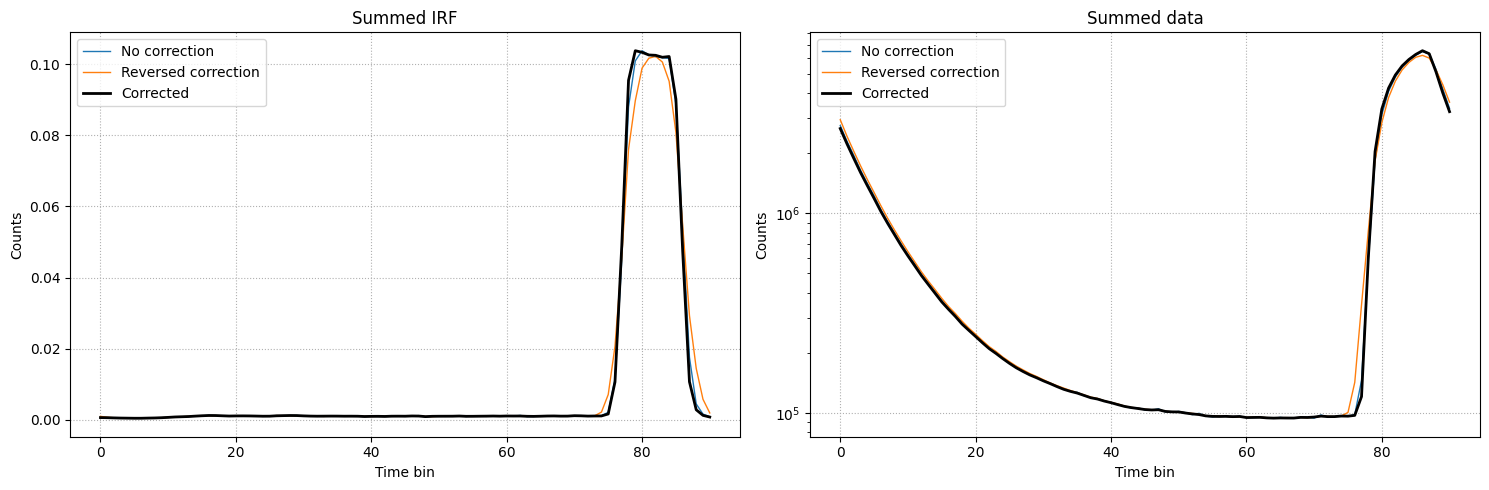

In [9]:
graph.plot_channel_skew_correction(
    irf_no_alignment=irf_summed_no_alignment,
    irf_aligned=irf_summed,
    irf_reversed=irf_summed_rev,
    data_no_alignment=data_summed_no_alignment,
    data_aligned=data_summed.sum(axis=(0, 1)),
    data_reversed=data_summed_rev.sum(axis=(0, 1)),
)



## Correct Phasors and Build Lifetime Maps

The raw phasors carry the phase and modulation distortion introduced by the instrument
(IRF, electronics, optical path). The correction strategy depends on `REFERENCE_TYPE`:

| `REFERENCE_TYPE` | Correction | Formula |
|---|---|---|
| `'ref'` | Divide by system response estimated from the reference dye | `phasor / (ref_measured / ref_theoretical)` |
| `'irf'` | Divide directly by the IRF phasor | `phasor / irf_phasor` |

After correction, two lifetime estimators are derived per pixel:
- **τ_m** (modulation lifetime): `τ_m = √(1/|p|² − 1) / ω` — sensitive to the width of the lifetime distribution.
- **τ_φ** (phase lifetime): `τ_φ = tan(φ) / ω` — sensitive to the mean lifetime.

For a pure mono-exponential emitter, τ_m = τ_φ. A difference between the two indicates
multi-exponential decay or FRET.


In [ ]:
intensity_map = data_summed.sum(axis=-1)

if REFERENCE_TYPE == 'ref':
    # Theoretical phasor of the monoexponential reference sample
    omega = 2 * np.pi * laser_freq_mhz * 1e6          # rad/s
    tau_ref_s = TAU_REF * 1e-9                          # ns → s
    ref_phasor_theoretical = 1.0 / (1.0 - 1j * omega * tau_ref_s)

    # The system response = measured_ref / theoretical_ref
    correction = ref_phasor / ref_phasor_theoretical

    print(f"Ref phasor misurato:  {ref_phasor:.6f}")
    print(f"Ref phasor teorico:   {ref_phasor_theoretical:.6f}")
    print(f"Correction factor:    {correction:.6f}")

else:  # REFERENCE_TYPE == 'irf'
    correction = irf_phasor

    #if  'complex' == "phase_only":
    #    irf_correction = irf_phasor / abs(irf_phasor)
    #else:
    #    irf_correction = irf_phasor


phasor_map   = h5_dataset_phasor_pix / correction
tau_m_map    = flim.calculate_tau_m(phasor_map,   dfd_freq=laser_freq_mhz * 1e6) * 1e9
tau_phi_map  = flim.calculate_tau_phi(phasor_map, dfd_freq=laser_freq_mhz * 1e6) * 1e9
lifetime_map = tau_m_map    # choose tau_m as the primary lifetime estimator

threshold = 0.05    # pixels below (threshold × max intensity) are excluded
thresholded_phasor_map    = flim.threshold_phasor(intensity_map, phasor_map, threshold)
thresholded_intensity_map = flim.threshold_intensity(intensity_map, threshold)
thresholded_tau_map, _, lifetime_mask = graph.threshold_lifetime_map(
    lifetime_map, intensity=intensity_map, threshold=threshold,
)

print("IRF phasor:", irf_phasor)
print("thresholded pixels:", thresholded_tau_map.size)



Ref phasor misurato:  0.752469-0.050473j
Ref phasor teorico:   0.716957+0.450477j
Correction factor:    0.720756-0.523264j
IRF phasor: (0.7022334237790656-0.5474108599744056j)
thresholded pixels: 151897


/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:603: RuntimeWarning: invalid value encountered in sqrt
  tau_m = np.sqrt((1. / (m ** 2)) - 1) / (2 * np.pi * dfd_freq)


Text(0.5, 1.0, 'Corrected phasor distribution')

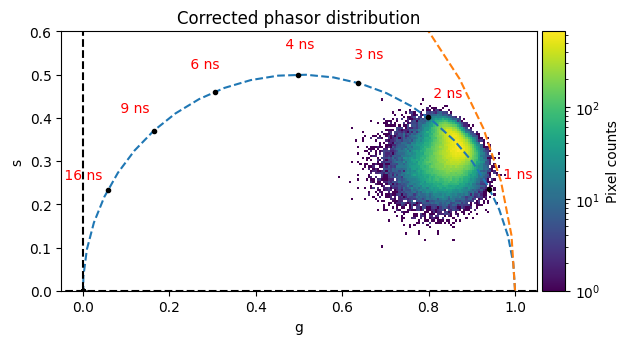

In [11]:
fig, ax = flim.plot_phasor(
    thresholded_phasor_map,
    quadrant="first",
    bins_2dplot=400,
    cmap="viridis",
    dfd_freq=laser_freq_mhz * 1e6,
)
ax.set_title("Corrected phasor distribution")



## τ_m / τ_φ Comparison

Comparing the two lifetime estimators gives insight into the complexity of the fluorescence decay:

- **Histograms** (left) — overlapping distributions of τ_m and τ_φ across all valid pixels.
- **Scatter plot** (centre) — τ_φ vs τ_m per pixel; points on the diagonal indicate mono-exponential behaviour.
- **Difference histogram** (right) — distribution of (τ_φ − τ_m); a peak at 0 indicates
  mono-exponential decay; a non-zero peak or broad distribution indicates multi-exponential decay or FRET.


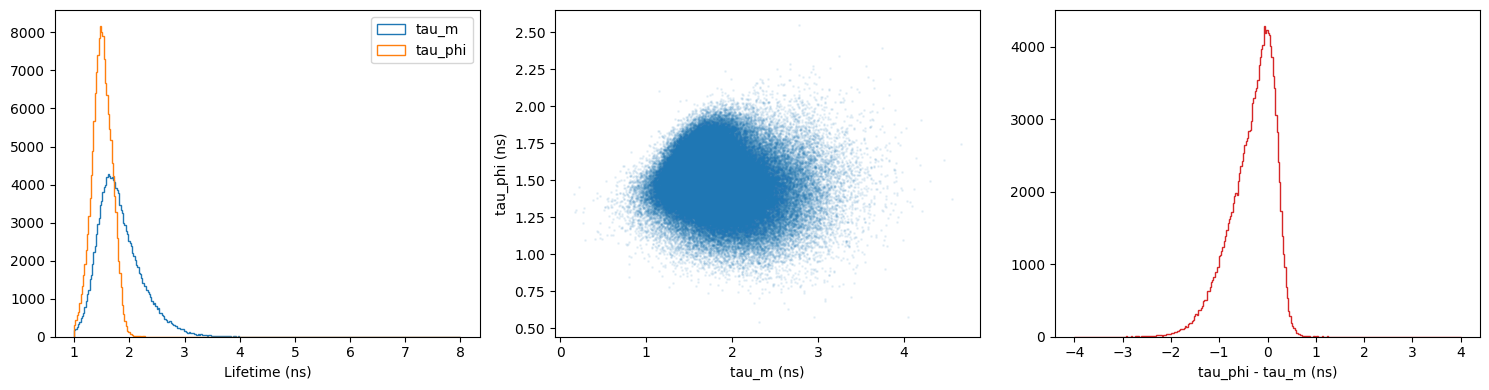

In [12]:
tau_compare_mask = (
    np.isfinite(tau_m_map)
    & np.isfinite(tau_phi_map)
    & np.isfinite(intensity_map)
    & (intensity_map > threshold * np.nanmax(intensity_map))
)

tau_m_compare   = tau_m_map[tau_compare_mask]
tau_phi_compare = tau_phi_map[tau_compare_mask]
tau_diff_compare = tau_phi_compare - tau_m_compare

fig, axs = plt.subplots(1, 3, figsize=(15, 4))
axs[0].hist(tau_m_compare,   bins=300, range=(1, 8), histtype="step", label="tau_m")
axs[0].hist(tau_phi_compare, bins=300, range=(1, 8), histtype="step", label="tau_phi")
axs[0].set_xlabel("Lifetime (ns)")
axs[0].legend()
axs[1].scatter(tau_m_compare, tau_phi_compare, s=1, alpha=0.08)
axs[1].set_xlabel("tau_m (ns)")
axs[1].set_ylabel("tau_phi (ns)")
axs[2].hist(tau_diff_compare, bins=300, range=(-4, 4), histtype="step", color="tab:red")
axs[2].set_xlabel("tau_phi - tau_m (ns)")
fig.tight_layout()



## Lifetime Visualisation

`plot_lifetime_summary` produces a multi-panel overview combining the intensity image,
the lifetime map (colour-coded by τ_m), and a weighted histogram of lifetime values.

`plot_equalized_lifetime_summary` applies a histogram-equalised colour mapping to the lifetime,
which improves contrast in samples where the lifetime distribution is narrow.

**Parameters to adjust:**
- `lifetime_bounds` — Colour scale limits for the lifetime map [ns].
- `crop` — Pixels to trim from each border (removes reconstruction edge artefacts).
- `colormap` — Any matplotlib colourmap (`"turbo"`, `"jet"`, `"magma"`, etc.).
- `weighted_histogram` — If `True`, each pixel is weighted by its intensity in the histogram.
- `equalization_strength` — Controls how aggressively the colour scale is equalised (higher = more contrast).


/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:687: RuntimeWarning: invalid value encountered in cast
  idx = (np.floor((variable - self.var_bounds[0]) / (self.var_bounds[1] - self.var_bounds[0]) * N)).astype(int)
/home/morlando1-iit.local/manuel/.venv/lib/python3.12/site-packages/brighteyes_ism/analysis/Graph_lib.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:727: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 1300x600 with 3 Axes>,
 (<Axes: title={'center': 'Lifetime map'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

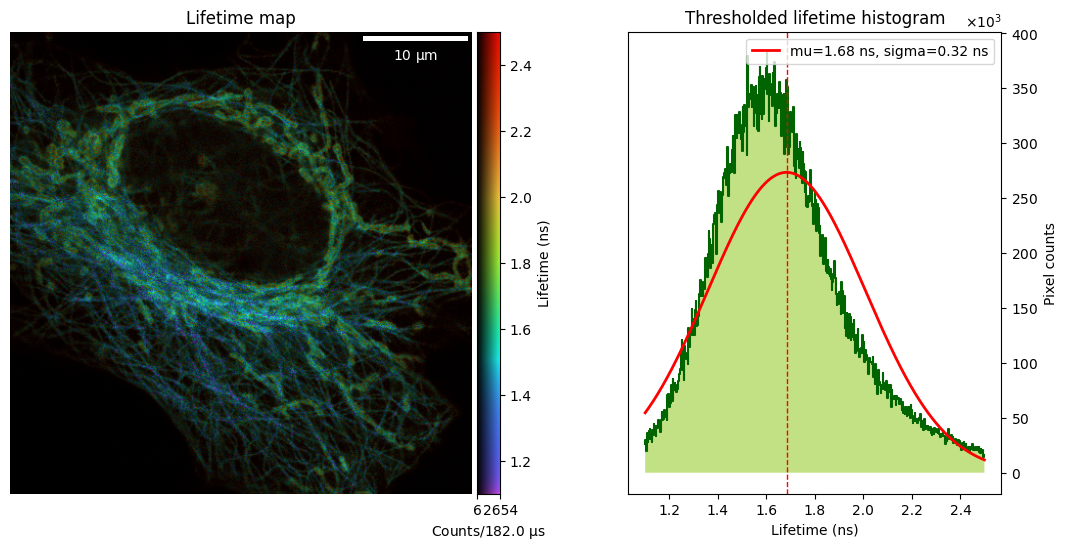

In [13]:
graph.plot_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.1, 2.5],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    weighted_histogram=True,
)



/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/tools_phasor.py:1098: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/home/morlando1-iit.local/manuel/BrightEyes-Flim/src/brighteyes_flim/graph_tools.py:807: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


(<Figure size 900x1800 with 5 Axes>,
 (<Axes: title={'center': 'Linear hue axis'}>,
  <Axes: title={'center': 'Equalized hue axis (strength=4.0, bins=4096)'}>,
  <Axes: title={'center': 'Thresholded lifetime histogram'}, xlabel='Lifetime (ns)', ylabel='Pixel counts'>))

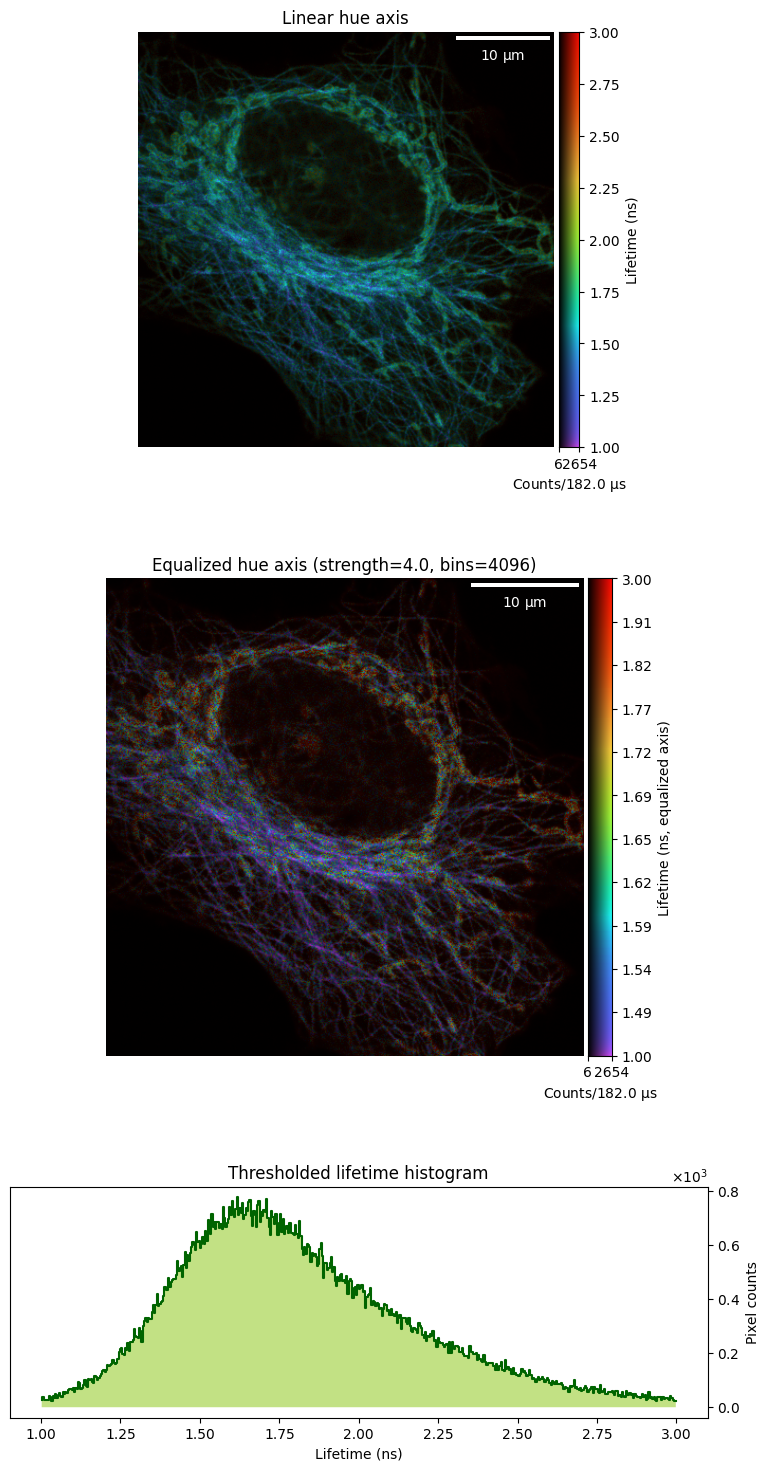

In [14]:
graph.plot_equalized_lifetime_summary(
    intensity=intensity_map,
    lifetime=lifetime_map,
    pxsize=pixel_size_x_um,
    pxdwelltime=pxdwelltime,
    lifetime_bounds=[1.0, 3.0],
    crop=30,
    threshold=threshold,
    bins=500,
    colormap="turbo",
    equalization_reference=thresholded_tau_map,
    equalization_strength=4.0,
    equalization_bins=4096,
    colorbar_ticks=12,
)



## Optional Export

`EXPORT_PATH` = enter the path and file name where the phasor plot will be saved (`.h5` format)

```python
EXPORT_PATH = r'C:\Users\REPLACE_ME\Desktop\Convallaria_PHASOR.h5'
if EXPORT_PATH:
    with h5py.File(EXPORT_PATH, "w") as hf:
        hf["intensity_map"]    = intensity_map
        hf["real"]             = np.real(phasor_map)
        hf["imag"]             = np.imag(phasor_map)
        hf["signal"]           = data_summed
        hf["irf_phasor_real"]  = np.real(irf_phasor)
        hf["irf_phasor_imag"]  = np.imag(irf_phasor)
```

In [15]:
#show_h5_structure_html(FILE_WITH_CALIBRATION)

